In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The text file is just raw numbers. We have to map the columns manually 
# based on the NASA readme file you provided.
cols = ['unit_number', 'time_cycles', 'setting_1', 'setting_2', 'setting_3']
cols += [f'sensor_{i}' for i in range(1, 22)]

# Load the file. It's separated by spaces, not commas.
df = pd.read_csv('../data/raw/train_FD001.txt', sep='\s+', header=None, names=cols)

df.head()

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Priya\AppData\Local\Temp\ipykernel_14040\2351692435.py:11: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('../data/raw/train_FD001.txt', sep='\s+', header=None, names=cols)


,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [2]:
# Find the exact cycle where each specific engine died (its maximum cycle)
max_cycles = df.groupby('unit_number')['time_cycles'].max().reset_index()
max_cycles.rename(columns={'time_cycles': 'max_cycle'}, inplace=True)

# Attach this 'max_cycle' info back to every single row in our main dataframe
df = df.merge(max_cycles, on='unit_number', how='left')

# The magic formula: How many cycles left?
df['RUL'] = df['max_cycle'] - df['time_cycles']

# Clean up by dropping the temporary column
df.drop('max_cycle', axis=1, inplace=True)

# Check our work for Engine 1
df[df['unit_number'] == 1][['unit_number', 'time_cycles', 'RUL']].tail()

,unit_number,time_cycles,RUL
187,1,188,4
188,1,189,3
189,1,190,2
190,1,191,1
191,1,192,0


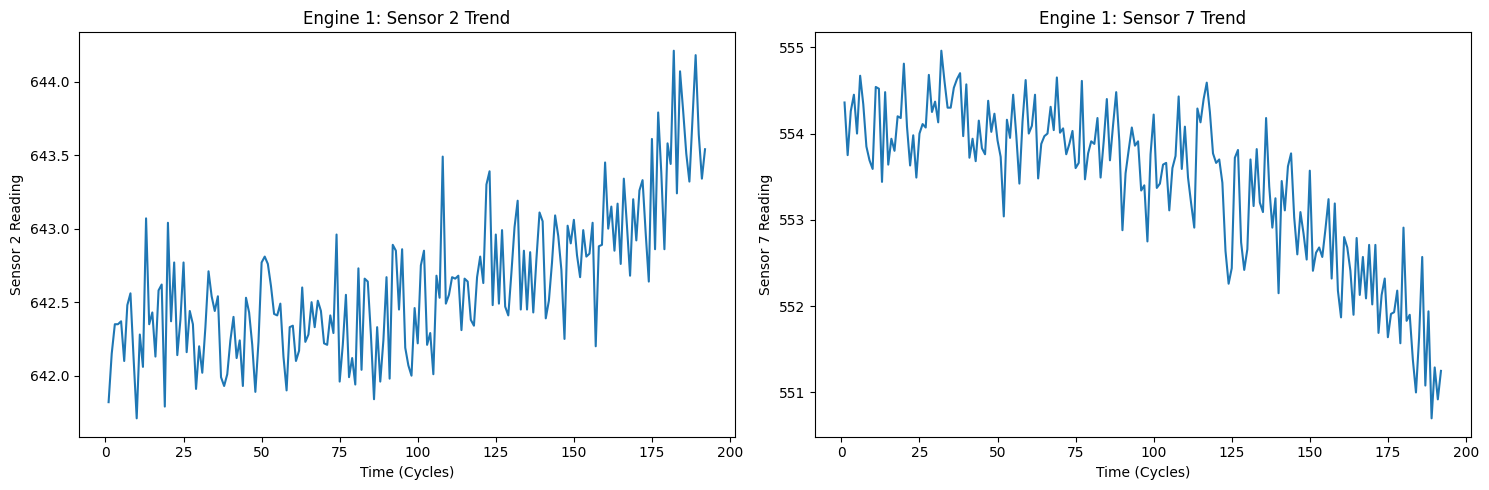

In [3]:
# Let's isolate Engine 1 to see how its sensors change as it approaches failure
engine_1 = df[df['unit_number'] == 1]

plt.figure(figsize=(15, 5))

# Plotting Sensor 2
plt.subplot(1, 2, 1)
sns.lineplot(data=engine_1, x='time_cycles', y='sensor_2')
plt.title('Engine 1: Sensor 2 Trend')
plt.xlabel('Time (Cycles)')
plt.ylabel('Sensor 2 Reading')

# Plotting Sensor 7
plt.subplot(1, 2, 2)
sns.lineplot(data=engine_1, x='time_cycles', y='sensor_7')
plt.title('Engine 1: Sensor 7 Trend')
plt.xlabel('Time (Cycles)')
plt.ylabel('Sensor 7 Reading')

plt.tight_layout()
plt.show()